# Parasite Segmentation with Colab
### Artificial Intelligence Winter School : Image segmentation
#### 2021.02.01

MAKE SURE YOU MAKE 'RUN_TYPE' TO "GPU"

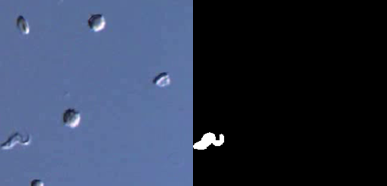

### INSTALL Libaries
We need...
  1. Segmentation models from
  https://github.com/qubvel/segmentation_models
  2. Tensorflow with version 2.1.0
  https://www.tensorflow.org/?hl=ko
  3. keras with version 2.3.1
  https://keras.io/


  **** DATASET LOCATION ****
  https://bit.ly/2NGNSq7


  


In [ ]:
!pip install segmentation-models
!pip install tensorflow==2.1.0
!pip install keras==2.3.1

### Connecting with Gdrive


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

In [ ]:
import glob
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
import tensorflow as tf
import segmentation_models as sm
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [ ]:
!pip install livelossplot

In [ ]:
SIZE_X = 256 #(height  = X, width = Y)
SIZE_Y = 256

#Capture training image info as a list
train_images = []

### DATASET Loading
Dataset location : '/content/gdrive/My Drive/AIWS/dataset'
origin_image : /dataset/AIWS_origin
mask_image : /dataset/AIWS_mask

Each folder contains 3,453 images with **256 pixels of height** and **256 pixels of width**

In [ ]:
print(os.listdir("/content/gdrive/My Drive/"))
SIZE_X = 256 #Resize images (height  = X, width = Y)
SIZE_Y = 256

#Capture training image info as a list
train_images = []
counter = 0
for directory_path in glob.glob("/content/gdrive/My Drive/AIWS/dataset/origin"):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        print(img_path)
        counter +=1
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        #img = cv2.resize(img, (SIZE_Y, SIZE_X))
        # img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_images.append(img)
#Convert list to array for machine learning processing
train_images = np.array(train_images)
print(train_images)



In [ ]:
#Capture mask/label info as a list
train_masks = []
counter =0
for directory_path in glob.glob("/content/gdrive/My Drive/AIWS/dataset/mask"):
    for mask_path in glob.glob(os.path.join(directory_path, "*.png")):
        print(mask_path)
        counter += 1
        mask = cv2.imread(mask_path, 0)
        #mask = cv2.resize(mask, (SIZE_Y, SIZE_X))
        #mask = cv2.cvtColor(mask, cv2.COLOR_RGB2BGR)
        train_masks.append(mask)
#Convert list to array for machine learning processing
train_masks = np.array(train_masks)

####Entire dataset : 3,453 images####

num_train : num_validation = 0.8 : 0.2


In [ ]:


#Use customary x_train and y_train variables
X = train_images
Y = train_masks
Y = np.expand_dims(Y, axis=3) #May not be necessary.. leftover from previous code
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
# preprocess input
x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)

## Training ##


In [ ]:
# define model
model = sm.Unet(BACKBONE, encoder_weights='imagenet')
model.compile(optimizer='Adam', loss=sm.losses.bce_jaccard_loss, metrics=[sm.metrics.iou_score])
print(model.summary())

history = model.fit(x = x_train,
          y = y_train,
          batch_size=32,
          epochs=30,
          verbose=1,
          validation_data=(x_val, y_val),)

"""
# Arguments
            x(real training): Input data. It could be:
            - A Numpy array (or array-like), or a list of arrays
              (in case the model has multiple inputs).

            y(mask training): Target data. Like the input data `x`

            validation_data(real testing, mask training): Data on which to evaluate
            the loss and any model metrics at the end of each epoch.
            The model will not be trained on this data.

# Returns
            A `History` object. Its `History.history` attribute is
            a record of training loss values and metrics values
            at successive epochs, as well as validation loss values
            and validation metrics values (if applicable).

"""

#accuracy = model.evaluate(x_val, y_val)
#plot the training and validation accuracy and loss at each epoch






### Evaluation

In [ ]:
loss = model.history['loss']
val_loss = model.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
iou = history.history['iou_score']
val_iou = history.history['val_iou_score']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, iou, 'y', label='iou')
plt.plot(epochs, val_iou, 'r', label='val_iou')
plt.title('iou')
plt.xlabel('Epochs')
plt.ylabel('iou')
plt.legend()
plt.show()

In [ ]:
f1 = history.history['f1-score']
val_f1 = history.history['val_f1-score']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, f1, 'y', label='f1')
plt.plot(epochs, val_f1, 'r', label='val_f1')
plt.title('f1')
plt.xlabel('Epochs')
plt.ylabel('f1')
plt.legend()
plt.show()

In [ ]:
model.save('/content/gdrive/My Drive/AIWS/parasite.h5')




In [ ]:
from tensorflow import keras
model = keras.models.load_model('/content/gdrive/My Drive/AIWS/parasite.h5', compile=False)
#Test on a different image
#READ EXTERNAL IMAGE...


### TEST ###

In [ ]:
test_img = cv2.imread('/content/gdrive/My Drive/AIWS/dataset/test/40x_4ms_14_F1_1.png', cv2.IMREAD_COLOR)
test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
test_img = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)
plt.imshow(test_img, cmap='gray')
test_img = np.expand_dims(test_img, axis=0)
prediction = model.predict(test_img)

In [ ]:
#View and Save segmented image
prediction_image = prediction.reshape(mask.shape)
plt.imshow(prediction_image)
#plt.imsave('/content/gdrive/My Drive/dataset/segA.png', prediction_image, cmap='gray')

### CHEAT ###
IF TEST did not work, use this model

In [ ]:
from tensorflow import keras
cheat_model = keras.models.load_model('/content/gdrive/My Drive/AIWS/cheat.h5', compile = False)

In [ ]:
test_img = cv2.imread('/content/gdrive/My Drive/AIWS/dataset/test/40x_4ms_14_F1_1.png', cv2.IMREAD_COLOR)
test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
test_img = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)
plt.imshow(test_img, cmap='gray')
test_img = np.expand_dims(test_img, axis=0)
prediction = cheat_model.predict(test_img)

In [ ]:
test_img = cv2.imread('/content/gdrive/My Drive/AIWS/dataset/answer/40x_4ms_14_F1_1.png', cv2.IMREAD_COLOR)

test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))

test_img = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)

plt.imshow(test_img, cmap='gray')

test_img = np.expand_dims(test_img, axis=0)

prediction = cheat_model.predict(test_img)



In [ ]:
#View and Save segmented image
prediction_image = prediction.reshape(mask.shape)
plt.imshow(prediction_image)
#plt.imsave('/content/gdrive/My Drive/dataset/segA.png', prediction_image, cmap='gray')